# Customer Purchase Propensity - Data Cleaning and Feature Engineering Pipeline

## Step 1: Project Planning and Problem Framing

- Data analysis means collecting, cleaning, exploring, and transforming raw data to get useful insights.
- A data science project normally includes problem understanding, data collection, cleaning, EDA, feature engineering, preprocessing, and model building.
- This project is a binary classification problem because the target has two classes: `purchased = 1` and `purchased = 0`.


In [9]:
import pandas as pd
import numpy as np
import sqlite3
import json
import urllib.request
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix

from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    Normalizer,
    FunctionTransformer,
    PowerTransformer
)

from sklearn.compose import ColumnTransformer


# Step 2: Data Import, Understanding & Mergging

In [10]:


customers = pd.read_csv("customers.csv")
transactions = pd.read_json("transactions.json")

conn = sqlite3.connect(":memory:")

with open("products.sql", "r", encoding="utf-8") as file:
    sql_script = file.read()

conn.executescript(sql_script)
products = pd.read_sql_query("SELECT * FROM products", conn)
conn.close()

url = "https://dummyjson.com/users"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

with urllib.request.urlopen(req) as response:
    api_data = json.load(response)

api_users = pd.DataFrame(api_data["users"]).head(len(customers))

print("Customers Data")
print(customers.head())
print()

print("Transactions Data")
print(transactions.head())
print()

print("Products Data")
print(products.head())
print()

print("API Users Data")
print(api_users.head())


Customers Data
   customer_id    name  age  gender       city  income
0          101   Aarav   24    Male     Mumbai   45000
1          102    Diya   30  Female      Delhi   55000
2          103   Kabir   27    Male  Bangalore   48000
3          104   Meera   35  Female  Ahmedabad   60000
4          105  Vivaan   40    Male       Pune   75000

Transactions Data
  transaction_id  customer_id product_id  amount payment_mode       date
0           T001          101       P001     499          UPI 2025-10-01
1           T002          103       P003    1299  Credit Card 2025-10-02
2           T003          104       P002     699   Debit Card 2025-10-03
3           T004          105       P005    1999          UPI 2025-10-05
4           T005          107       P004     899         Cash 2025-10-07

Products Data
  product_id       product_name     category  price  stock
0       P001          Earphones  Electronics    499     50
1       P002  Bluetooth Speaker        Audio    699     40
2     

In [11]:
api_users["name"] = api_users["firstName"] + " " + api_users["lastName"]
api_users["city"] = api_users["address"].apply(lambda x: x["city"])

api_customers = api_users[["id", "name", "age", "gender", "city"]].copy()
api_customers = api_customers.rename(columns={"id": "customer_id"})
api_customers["gender"] = api_customers["gender"].str.title()
api_customers["income"] = np.nan
api_customers["transaction_id"] = np.nan
api_customers["product_id"] = np.nan
api_customers["amount"] = np.nan
api_customers["payment_mode"] = np.nan
api_customers["date"] = np.nan
api_customers["product_name"] = np.nan
api_customers["category"] = np.nan
api_customers["price"] = np.nan
api_customers["stock"] = np.nan
api_customers["purchased"] = 0
api_customers["total_purchases"] = 0

local_data = pd.merge(customers, transactions, on="customer_id", how="left")
local_data = pd.merge(local_data, products, on="product_id", how="left")
local_data["gender"] = local_data["gender"].str.title()
local_data["purchased"] = local_data["amount"].notnull().astype(int)
local_data["total_purchases"] = local_data["purchased"]

common_cols = [
    "customer_id", "name", "age", "gender", "city", "income",
    "transaction_id", "product_id", "amount", "payment_mode", "date",
    "product_name", "category", "price", "stock", "purchased", "total_purchases"
]

full_data = pd.concat([local_data[common_cols], api_customers[common_cols]], ignore_index=True)

print("Merged Data Head")
print(full_data.head())
print()

print("Merged Data Info")
full_data.info()
print()

print("Merged Data Describe")
print(full_data.describe(include="all"))


Merged Data Head
   customer_id    name  age  gender       city   income transaction_id  \
0          101   Aarav   24    Male     Mumbai  45000.0           T001   
1          102    Diya   30  Female      Delhi  55000.0           T007   
2          103   Kabir   27    Male  Bangalore  48000.0           T002   
3          104   Meera   35  Female  Ahmedabad  60000.0           T003   
4          105  Vivaan   40    Male       Pune  75000.0           T004   

  product_id  amount payment_mode       date       product_name     category  \
0       P001   499.0          UPI 2025-10-01          Earphones  Electronics   
1       P003  1499.0  Credit Card 2025-10-09        Smart Watch     Wearable   
2       P003  1299.0  Credit Card 2025-10-02        Smart Watch     Wearable   
3       P002   699.0   Debit Card 2025-10-03  Bluetooth Speaker        Audio   
4       P005  1999.0          UPI 2025-10-05         Headphones        Audio   

    price  stock  purchased  total_purchases  
0   499.0 

C:\Users\patel\AppData\Local\Temp\ipykernel_19844\1795431014.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_data = pd.concat([local_data[common_cols], api_customers[common_cols]], ignore_index=True)


# Step 3: Exploratory Data Analysis (EDA), Bivariate and Multivariate Analysis

Target Count
purchased
1    8
0    8
Name: count, dtype: int64



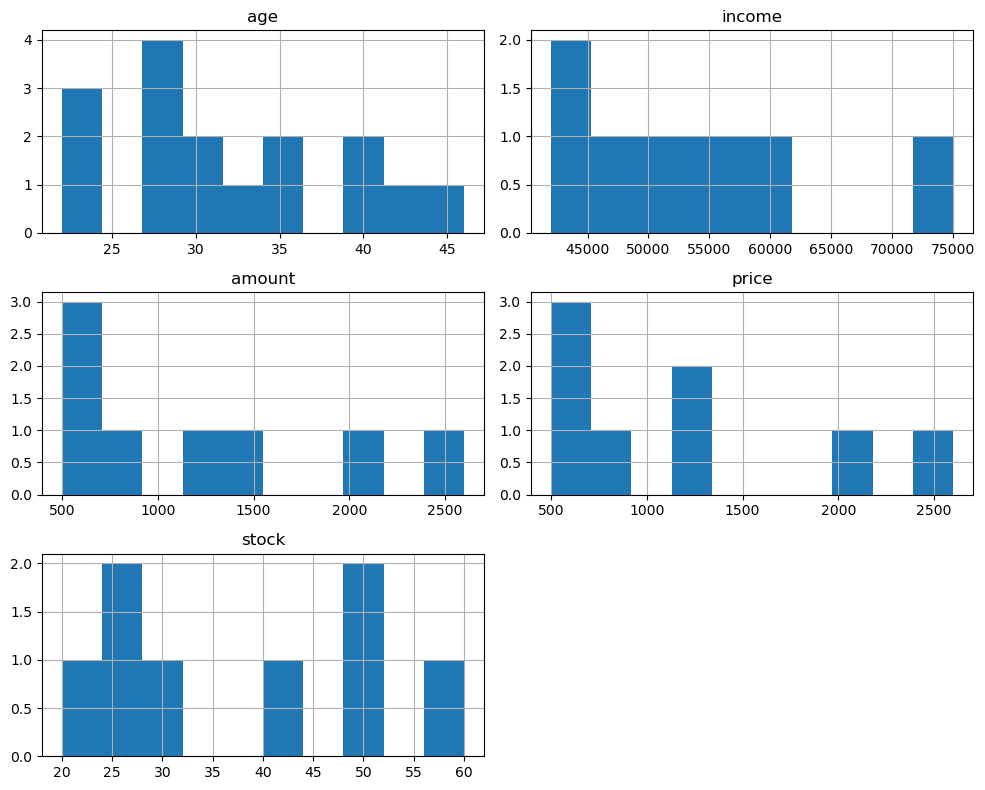

Skewness
age       0.439558
income    1.073956
amount    0.813569
price     0.960237
stock     0.341565
dtype: float64


In [12]:
eda_data = full_data.copy()
numeric_cols = ["age", "income", "amount", "price", "stock"]

print("Target Count")
print(eda_data["purchased"].value_counts())
print()

eda_data[numeric_cols].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

print("Skewness")
print(eda_data[numeric_cols].skew(numeric_only=True))


Correlation with Target
                age    income    amount     price     stock  purchased
age        1.000000 -0.169326 -0.026646 -0.022040 -0.399028  -0.316473
income    -0.169326  1.000000  0.853881  0.851339  0.807395   0.968646
amount    -0.026646  0.853881  1.000000  0.998260  0.467770   0.780625
price     -0.022040  0.851339  0.998260  1.000000  0.470371   0.776939
stock     -0.399028  0.807395  0.467770  0.470371  1.000000   0.888523
purchased -0.316473  0.968646  0.780625  0.776939  0.888523   1.000000

Grouped Mean by Purchased
              age   income  amount   price  stock
purchased                                        
0          34.375      NaN     NaN     NaN    NaN
1          30.000  54125.0  1249.0  1224.0   37.5



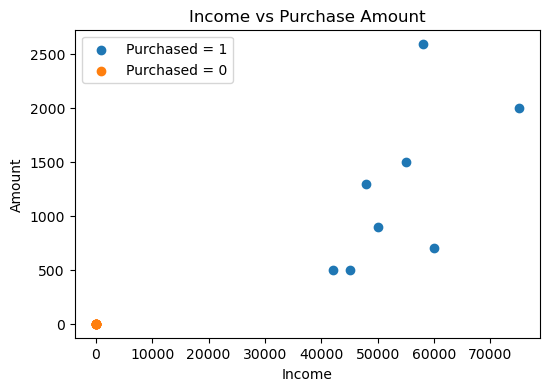

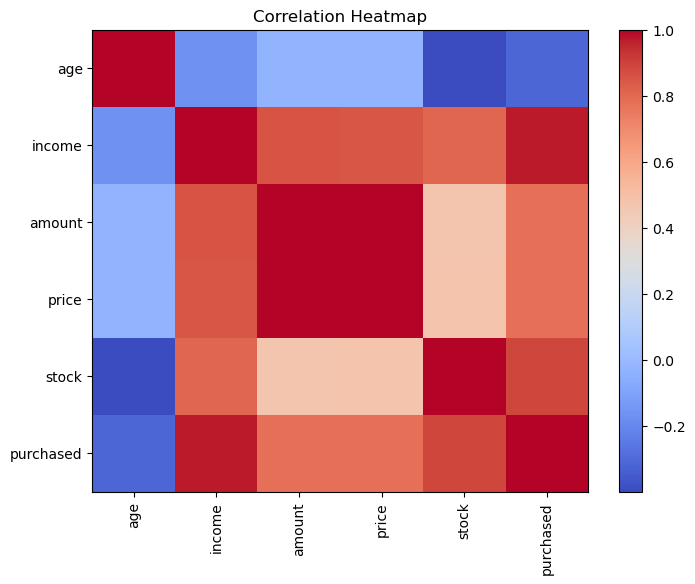

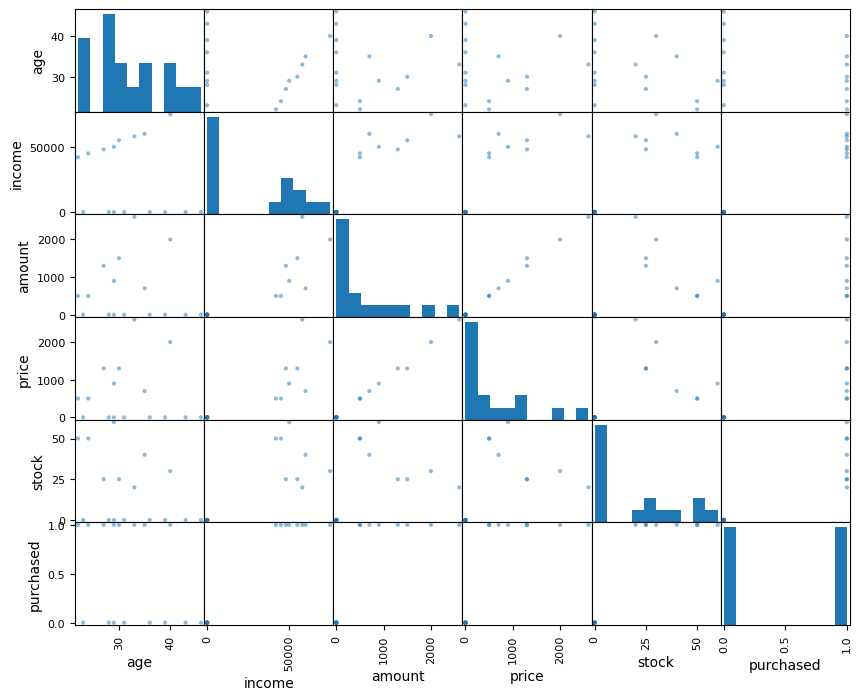

In [13]:
corr_data = eda_data[numeric_cols + ["purchased"]].fillna(0)

print("Correlation with Target")
print(corr_data.corr())
print()

print("Grouped Mean by Purchased")
print(eda_data.groupby("purchased")[numeric_cols].mean())
print()

buyers = eda_data[eda_data["purchased"] == 1]
non_buyers = eda_data[eda_data["purchased"] == 0]

plt.figure(figsize=(6, 4))
plt.scatter(buyers["income"], buyers["amount"], label="Purchased = 1")
plt.scatter(non_buyers["income"].fillna(0), non_buyers["amount"].fillna(0), label="Purchased = 0")
plt.xlabel("Income")
plt.ylabel("Amount")
plt.title("Income vs Purchase Amount")
plt.legend()
plt.show()

corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.show()

scatter_matrix(corr_data, figsize=(10, 8))
plt.show()



# Step 4: Handling Missing Data

In [14]:
step4_data = full_data.copy()

print("Missing Values")
print(step4_data.isnull().sum())
print()

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

step4_data["income_simple"] = num_imputer.fit_transform(step4_data[["income"]]).ravel()
step4_data["category_simple"] = cat_imputer.fit_transform(step4_data[["category"]]).ravel()
step4_data["payment_mode_simple"] = cat_imputer.fit_transform(step4_data[["payment_mode"]]).ravel()

indicator = MissingIndicator(features="all")
step4_data["income_missing_flag"] = indicator.fit_transform(step4_data[["income"]]).ravel().astype(int)

step4_data["income_random"] = step4_data["income"]
missing_count = step4_data["income_random"].isnull().sum()

if missing_count > 0:
    random_values = step4_data["income"].dropna().sample(missing_count, replace=True, random_state=42).values
    step4_data.loc[step4_data["income_random"].isnull(), "income_random"] = random_values

print(step4_data[[
    "income", "income_simple", "income_random",
    "category", "category_simple",
    "payment_mode", "payment_mode_simple",
    "income_missing_flag"
]].head())


Missing Values
customer_id        0
name               0
age                0
gender             0
city               0
income             8
transaction_id     8
product_id         8
amount             8
payment_mode       8
date               8
product_name       8
category           8
price              8
stock              8
purchased          0
total_purchases    0
dtype: int64

    income  income_simple  income_random     category category_simple  \
0  45000.0        45000.0        45000.0  Electronics     Electronics   
1  55000.0        55000.0        55000.0     Wearable        Wearable   
2  48000.0        48000.0        48000.0     Wearable        Wearable   
3  60000.0        60000.0        60000.0        Audio           Audio   
4  75000.0        75000.0        75000.0        Audio           Audio   

  payment_mode payment_mode_simple  income_missing_flag  
0          UPI                 UPI                    0  
1  Credit Card         Credit Card                    0  
2

# Step 5: Outlier Detection and Handling

In [15]:
step5_data = step4_data.copy()

step5_data["amount_fill"] = step5_data["amount"].fillna(0)
step5_data["price_fill"] = step5_data["price"].fillna(0)
step5_data["stock_fill"] = step5_data["stock"].fillna(0)

mean_amount = step5_data["amount_fill"].mean()
std_amount = step5_data["amount_fill"].std()

if std_amount != 0:
    step5_data["amount_zscore"] = (step5_data["amount_fill"] - mean_amount) / std_amount
else:
    step5_data["amount_zscore"] = 0

step5_data["amount_z_outlier"] = step5_data["amount_zscore"].abs() > 3

Q1 = step5_data["income_simple"].quantile(0.25)
Q3 = step5_data["income_simple"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

step5_data["income_iqr_outlier"] = (
    (step5_data["income_simple"] < lower_limit) |
    (step5_data["income_simple"] > upper_limit)
)

lower_p = step5_data["price_fill"].quantile(0.05)
upper_p = step5_data["price_fill"].quantile(0.95)

step5_data["price_percentile_outlier"] = (
    (step5_data["price_fill"] < lower_p) |
    (step5_data["price_fill"] > upper_p)
)

lower_cap = step5_data["amount_fill"].quantile(0.05)
upper_cap = step5_data["amount_fill"].quantile(0.95)

step5_data["amount_winsorized"] = step5_data["amount_fill"].clip(lower=lower_cap, upper=upper_cap)
step5_data["income_capped"] = step5_data["income_simple"].clip(lower=lower_limit, upper=upper_limit)

print(step5_data[[
    "amount_fill", "amount_zscore", "amount_z_outlier",
    "income_simple", "income_iqr_outlier",
    "price_fill", "price_percentile_outlier",
    "amount_winsorized", "income_capped"
]].head())

print("Z-score outliers:", step5_data["amount_z_outlier"].sum())
print("IQR outliers:", step5_data["income_iqr_outlier"].sum())
print("Percentile outliers:", step5_data["price_percentile_outlier"].sum())


   amount_fill  amount_zscore  amount_z_outlier  income_simple  \
0        499.0      -0.151894             False        45000.0   
1       1499.0       1.058414             False        55000.0   
2       1299.0       0.816352             False        48000.0   
3        699.0       0.090168             False        60000.0   
4       1999.0       1.663567             False        75000.0   

   income_iqr_outlier  price_fill  price_percentile_outlier  \
0                True       499.0                     False   
1               False      1299.0                     False   
2                True      1299.0                     False   
3                True       699.0                     False   
4                True      1999.0                     False   

   amount_winsorized  income_capped  
0              499.0        50000.0  
1             1499.0        55000.0  
2             1299.0        50000.0  
3              699.0        55000.0  
4             1999.0        55000.

# Step 6: Handling Mixed and Date/Time Variables

In [16]:
step6_data = step5_data.copy()

reference_date = pd.to_datetime("2025-10-15")

step6_data["last_purchase_date"] = pd.to_datetime(step6_data["date"])
step6_data["signup_date"] = reference_date - pd.to_timedelta((step6_data["customer_id"] % 30) + 30, unit="D")

step6_data["days_since_last_purchase"] = (reference_date - step6_data["last_purchase_date"]).dt.days
step6_data["days_since_signup"] = (reference_date - step6_data["signup_date"]).dt.days

step6_data["customer_code"] = "CUST" + step6_data["customer_id"].astype(str)
step6_data["customer_number"] = step6_data["customer_code"].str.extract(r"(\d+)").astype(int)

print(step6_data[[
    "customer_id", "customer_code", "customer_number",
    "signup_date", "last_purchase_date",
    "days_since_signup", "days_since_last_purchase"
]].head())


   customer_id customer_code  customer_number signup_date last_purchase_date  \
0          101       CUST101              101  2025-09-04         2025-10-01   
1          102       CUST102              102  2025-09-03         2025-10-09   
2          103       CUST103              103  2025-09-02         2025-10-02   
3          104       CUST104              104  2025-09-01         2025-10-03   
4          105       CUST105              105  2025-08-31         2025-10-05   

   days_since_signup  days_since_last_purchase  
0                 41                      14.0  
1                 42                       6.0  
2                 43                      13.0  
3                 44                      12.0  
4                 45                      10.0  


# Step 7: Encoding Categorical Data

In [17]:
step7_data = step6_data.copy()

step7_data["income_group"] = pd.cut(
    step7_data["income_simple"],
    bins=[-1, 50000, 65000, float("inf")],
    labels=["Low", "Medium", "High"]
)

label_encoder = LabelEncoder()
step7_data["gender_label"] = label_encoder.fit_transform(step7_data["gender"])

ordinal_encoder = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
step7_data["income_group_encoded"] = ordinal_encoder.fit_transform(step7_data[["income_group"]]).ravel().astype(int)

city_dummies = pd.get_dummies(step7_data["city"], prefix="city")
payment_dummies = pd.get_dummies(step7_data["payment_mode_simple"], prefix="payment")

encoded_data = pd.concat([step7_data, city_dummies, payment_dummies], axis=1)

print(encoded_data[[
    "gender", "gender_label", "income_group", "income_group_encoded"
]].head())

print(city_dummies.head())
print(payment_dummies.head())


   gender  gender_label income_group  income_group_encoded
0    Male             1          Low                     0
1  Female             0       Medium                     1
2    Male             1          Low                     0
3  Female             0       Medium                     1
4    Male             1         High                     2
   city_Ahmedabad  city_Bangalore  city_Chennai  city_Delhi  city_Fort Worth  \
0           False           False         False       False            False   
1           False           False         False        True            False   
2           False            True         False       False            False   
3            True           False         False       False            False   
4           False           False         False       False            False   

   city_Houston  city_Indianapolis  city_Jacksonville  city_Kolkata  \
0         False              False              False         False   
1         False        

# Step 8: Feature Scaling

In [18]:
step8_data = encoded_data.copy()

scale_cols = [
    "age", "income_simple", "amount_fill",
    "price_fill", "stock_fill",
    "days_since_signup", "days_since_last_purchase"
]

scale_data = step8_data[scale_cols].fillna(0)

standard_scaled = pd.DataFrame(
    StandardScaler().fit_transform(scale_data),
    columns=[col + "_standard" for col in scale_cols]
)

minmax_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(scale_data),
    columns=[col + "_minmax" for col in scale_cols]
)

maxabs_scaled = pd.DataFrame(
    MaxAbsScaler().fit_transform(scale_data),
    columns=[col + "_maxabs" for col in scale_cols]
)

robust_scaled = pd.DataFrame(
    RobustScaler().fit_transform(scale_data),
    columns=[col + "_robust" for col in scale_cols]
)

normalizer_scaled = pd.DataFrame(
    Normalizer().fit_transform(scale_data),
    columns=[col + "_normalizer" for col in scale_cols]
)

column_transformer = ColumnTransformer(
    transformers=[
        ("standard", StandardScaler(), ["age", "income_simple"]),
        ("minmax", MinMaxScaler(), ["amount_fill", "price_fill"]),
        ("robust", RobustScaler(), ["stock_fill", "days_since_signup", "days_since_last_purchase"])
    ]
)

ct_result = pd.DataFrame(column_transformer.fit_transform(scale_data))

print("Standard Scaler")
print(standard_scaled.head())
print()

print("MinMax Scaler")
print(minmax_scaled.head())
print()

print("MaxAbs Scaler")
print(maxabs_scaled.head())
print()

print("Robust Scaler")
print(robust_scaled.head())
print()

print("Normalizer")
print(normalizer_scaled.head())
print()

print("ColumnTransformer Result")
print(ct_result.head())


Standard Scaler
   age_standard  income_simple_standard  amount_fill_standard  \
0     -1.184514               -1.189445             -0.156875   
1     -0.316473                0.241466              1.093125   
2     -0.750494               -0.760172              0.843125   
3      0.406894                0.956922              0.093125   
4      1.130262                3.103290              1.718125   

   price_fill_standard  stock_fill_standard  days_since_signup_standard  \
0            -0.143454             1.480872                    0.272727   
1             0.872152             0.296174                    0.454545   
2             0.872152             0.296174                    0.636364   
3             0.110447             1.006993                    0.818182   
4             1.760808             0.533114                    1.000000   

   days_since_last_purchase_standard  
0                           1.793359  
1                           0.252755  
2                        

# Step 9: Feature Construction and Transformation

In [22]:
step9_data = step8_data.copy()

# safe division
step9_data["purchase_per_day"] = step9_data["total_purchases"] / step9_data["days_since_signup"].replace(0, 1)

# transformations
step9_data["amount_log"] = np.log1p(step9_data["amount_fill"])
step9_data["amount_sqrt"] = np.sqrt(step9_data["amount_fill"])
step9_data["amount_reciprocal"] = 1 / (step9_data["amount_fill"] + 1)

power_transformer = PowerTransformer(method="yeo-johnson")
step9_data["amount_power"] = power_transformer.fit_transform(step9_data[["amount_fill"]]).flatten()

# binning
step9_data["income_bin"] = pd.cut(
    step9_data["income_simple"],
    bins=[-1, 50000, 65000, float("inf")],
    labels=["Low", "Medium", "High"]
)

# binarization
step9_data["frequent_buyer"] = (step9_data["total_purchases"] >= 1).astype(int)

print(step9_data[[
    "total_purchases", "days_since_signup", "purchase_per_day",
    "amount_fill", "amount_log", "amount_sqrt",
    "amount_reciprocal", "amount_power",
    "income_bin", "frequent_buyer"
]].head())


   total_purchases  days_since_signup  purchase_per_day  amount_fill  \
0                1                 41          0.024390        499.0   
1                1                 42          0.023810       1499.0   
2                1                 43          0.023256       1299.0   
3                1                 44          0.022727        699.0   
4                1                 45          0.022222       1999.0   

   amount_log  amount_sqrt  amount_reciprocal  amount_power income_bin  \
0    6.214608    22.338308           0.002000      0.790589        Low   
1    7.313220    38.716921           0.000667      1.087907     Medium   
2    7.170120    36.041643           0.000769      1.049476        Low   
3    6.551080    26.438608           0.001429      0.882207     Medium   
4    7.600902    44.710178           0.000500      1.164899       High   

   frequent_buyer  
0               1  
1               1  
2               1  
3               1  
4               1  


# Step 10: Final Output

In [23]:
processed_customer_data = pd.concat([
    step9_data[[
        "customer_id", "purchased", "gender_label",
        "income_group_encoded", "income_missing_flag",
        "purchase_per_day", "amount_log", "amount_sqrt",
        "amount_reciprocal", "amount_power", "frequent_buyer"
    ]].reset_index(drop=True),
    city_dummies.reset_index(drop=True),
    payment_dummies.reset_index(drop=True),
    robust_scaled.reset_index(drop=True)
], axis=1)

processed_customer_data.to_csv("processed_customer_data.csv", index=False)

print("Final Processed Data")
print(processed_customer_data.head())
print()

print("Final Shape:", processed_customer_data.shape)
print("CSV file saved as processed_customer_data.csv")


Final Processed Data
   customer_id  purchased  gender_label  income_group_encoded  \
0          101          1             1                     0   
1          102          1             0                     1   
2          103          1             1                     0   
3          104          1             0                     1   
4          105          1             1                     2   

   income_missing_flag  purchase_per_day  amount_log  amount_sqrt  \
0                    0          0.024390    6.214608    22.338308   
1                    0          0.023810    7.313220    38.716921   
2                    0          0.023256    7.170120    36.041643   
3                    0          0.022727    6.551080    26.438608   
4                    0          0.022222    7.600902    44.710178   

   amount_reciprocal  amount_power  ...  payment_Credit Card  \
0           0.002000      0.790589  ...                False   
1           0.000667      1.087907  ...      